In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from surprise import Dataset, Reader, SVD, accuracy
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from joblib import Parallel, delayed
import time

### Этап 1: знакомство с данными и EDA (Exploratory Data Analysis)

 #### 1. Загрузка данных: ratings.csv, books.csv, tags.csv, book_tags.csv.

In [2]:
# Загрузка датасета
ratings = pd.read_csv("ratings.csv")
books = pd.read_csv("books.csv")
tags = pd.read_csv("tags.csv")
book_tags = pd.read_csv("book_tags.csv")

In [3]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981756 entries, 0 to 981755
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   book_id  981756 non-null  int64
 1   user_id  981756 non-null  int64
 2   rating   981756 non-null  int64
dtypes: int64(3)
memory usage: 22.5 MB


In [4]:
ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


ratings содержит оценки пользователей книг.

* user_id - Идентификатор пользователя
* book_id - ID книги (1–10000). Совпадает с books.book_id.
* rating - Оценка, выставленная пользователем книге, по шкале от 1 до 5.

In [5]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   book_id                    10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

In [6]:
books.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


books содержит метаданные о 10 000 книгах из Goodreads

* id – Идентификатор книги на Goodreads (уникальный для конкретного издания). Используется для внешних ссылок и API.
* book_id – Внутренний идентификатор книги в наборе данных (1–10000). Совпадает с ratings.book_id.
*  best_book_id – ID «лучшего издания» книги на Goodreads. Совпадает с book_tags.goodreads_book_id.
* work_id – Идентификатор произведения (Work ID) на Goodreads, объединяющий все издания одной книги.
* books_count – Количество различных изданий данной книги, зарегистрированных на Goodreads.
* isbn – 10-значный международный стандартный книжный номер (может отсутствовать).
* isbn13 – 13-значный ISBN (может отсутствовать).
* authors – Имя автора или нескольких авторов книги.
* original_publication_year – Год первой публикации книги (может содержать пропуски).
* original_title – Оригинальное название книги (до перевода или переиздания, может отсутствовать).
* title – Название книги (может отличаться от оригинального).
* language_code – Код языка книги (например, eng, spa, fre). Может содержать пропуски.
* average_rating – Средняя оценка книги по данным Goodreads.
* ratings_count – Количество оценок данного издания книги.
* work_ratings_count – Количество оценок всех изданий книги (работы).
* work_text_reviews_count – Количество текстовых отзывов по работе в целом.
* ratings_1–ratings_5 – Количество оценок с 1 по 5 звёзд.
* image_url – Ссылка на изображение обложки книги.
* small_image_url – Ссылка на уменьшенное изображение обложки книги.

In [7]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34252 entries, 0 to 34251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tag_id    34252 non-null  int64 
 1   tag_name  34252 non-null  object
dtypes: int64(1), object(1)
memory usage: 535.3+ KB


In [8]:
tags

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-
...,...,...
34247,34247,Ｃhildrens
34248,34248,Ｆａｖｏｒｉｔｅｓ
34249,34249,Ｍａｎｇａ
34250,34250,ＳＥＲＩＥＳ


tags.csv содержит справочник тегов.

* tag_id – Уникальный идентификатор тега.
* tag_name – Название тега (может содержать дубликаты, шум и нестандартные символы; требует предобработки перед использованием).

In [9]:
book_tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999912 entries, 0 to 999911
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   goodreads_book_id  999912 non-null  int64
 1   tag_id             999912 non-null  int64
 2   count              999912 non-null  int64
dtypes: int64(3)
memory usage: 22.9 MB


In [10]:
book_tags.head()

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716


book_tags.csv содержит связи между книгами и тегами, показывая, какие теги и как часто пользователи применяли к каждой книге.

* goodreads_book_id – Идентификатор книги на Goodreads. Совпадает с books.best_book_id.
* tag_id – Идентификатор тега (ссылается на tags.tag_id).
* count – Количество раз, когда данный тег был присвоен этой книге пользователями.

In [11]:
# Функция для проверки пропусков и дубликатов
def check_dataset(df, name, subset=None):
    print(f"\n{name}")
    print(f"Размер: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
    print("Пропущенные значения:")
    print(df.isna().sum())
    
    duplicates = df.duplicated(subset=subset).sum()
    if subset:
        print(f"Дубликаты по {subset}: {duplicates}")
    else:
        print(f"Полные дубликаты строк: {duplicates}")

In [12]:
# Проверяем все датасеты
check_dataset(ratings, "ratings", subset=['user_id', 'book_id'])
check_dataset(books, "books", subset=['book_id'])
check_dataset(tags, "tags", subset=['tag_id'])
check_dataset(book_tags, "book_tags", subset=['goodreads_book_id', 'tag_id'])


ratings
Размер: 981,756 строк, 3 столбцов
Пропущенные значения:
book_id    0
user_id    0
rating     0
dtype: int64
Дубликаты по ['user_id', 'book_id']: 2278

books
Размер: 10,000 строк, 23 столбцов
Пропущенные значения:
id                              0
book_id                         0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          700
isbn13                        585
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
image_url                       0
small_image_url               

* В raitings jбнаружено 2 278 дубликатов по паре (user_id, book_id) — значит, некоторые пользователи ставили одной книге несколько оценок.
* В books пропуски присутствуют только в текстовых и справочных полях — на анализ оценок и рекомендации это не влияет напрямую.
* В book_tags 8 дубликатов по паре (goodreads_book_id, tag_id), это значит, что одна и та же книга и тег встречаются несколько раз.

In [13]:
# Удаление дубликатов
ratings = ratings.drop_duplicates(subset=['user_id', 'book_id'])
book_tags = book_tags.drop_duplicates(subset=['goodreads_book_id', 'tag_id'])

# Проверка результатов
print("ratings после удаления дубликатов:", ratings.shape)
print("book_tags после удаления дубликатов:", book_tags.shape)

ratings после удаления дубликатов: (979478, 3)
book_tags после удаления дубликатов: (999904, 3)


In [14]:
# Заполнение пропусков в original_title комбинацией ID и автора
books['original_title'] = books['original_title'].fillna(
    'Unknown_' + books['book_id'].astype(str) + '_' + books['authors']
)

# Проверим результат
books['original_title'].isna().sum()


0

#### 2. Разведочный анализ:
##### Распределение оценок. Есть ли смещение в сторону высоких оценок?
##### Анализ активности пользователей. Постройте график «Взаимоотношение количества пользователей и количества оценок». Выявите активных пользователей и пользователей с малым количеством взаимодействий (проблема холодного старта).
##### Анализ популярности книг. Постройте график «Количество книг vs количество оценок». Выявите популярные книги и «длинный хвост».
##### Визуализируйте самые частые теги для книг (на основе book_tags.csv).

ОСНОВНАЯ СТАТИСТИКА:
уникальных пользователей: 53,424
уникальных книг: 10,000
всего оценок: 979,478
разреженность матрицы: 99.8167%


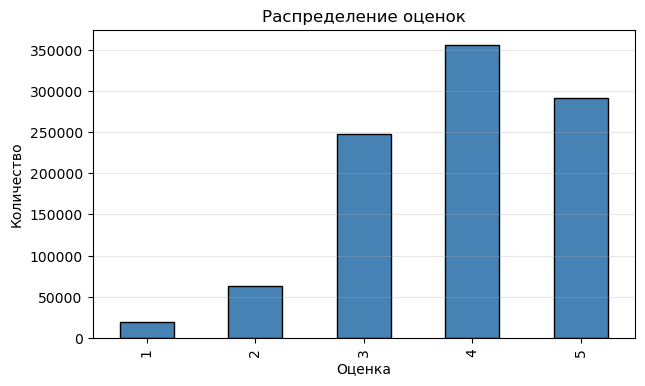

Средняя оценка: 3.86

Распределение оценок (в долях):
rating
1    0.019939
2    0.064438
3    0.253343
4    0.364092
5    0.298187
Name: proportion, dtype: float64

АКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ:
Среднее число оценок на пользователя: 18.3
Медиана: 8.0
Максимум: 200
Пользователей с 1 оценкой: 42


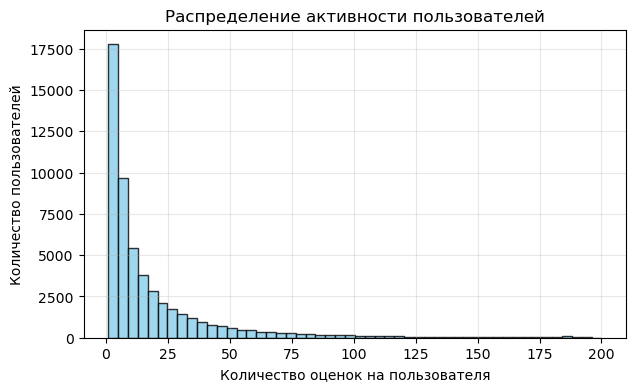


ПОПУЛЯРНОСТЬ КНИГ:
Среднее число оценок на книгу: 97.9
Медиана: 100.0
Максимум: 100
Книг с 1 оценкой: 0


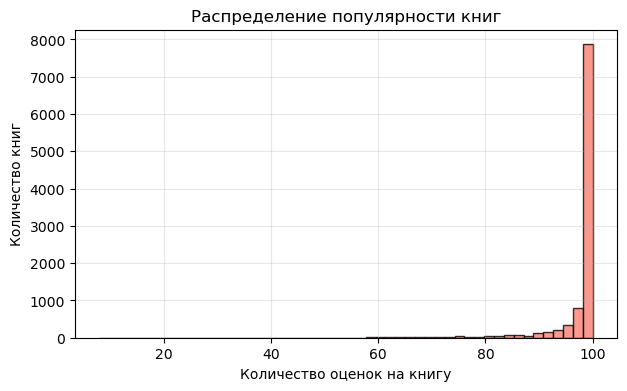

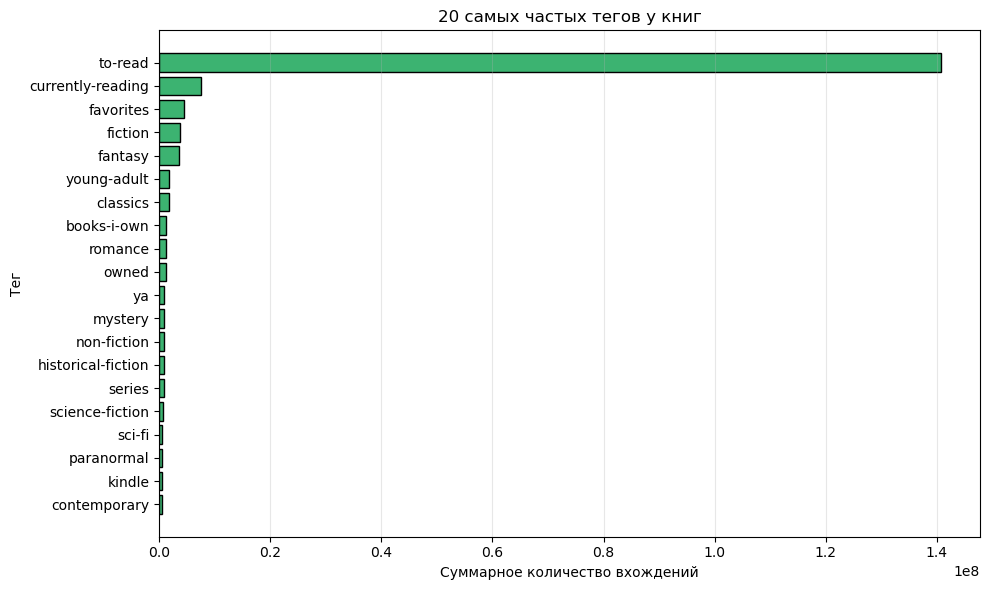


Анализ данных завершен.


In [15]:
# Основная статистика
n_users = ratings['user_id'].nunique()
n_books = ratings['book_id'].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_books))

print("ОСНОВНАЯ СТАТИСТИКА:")
print(f"уникальных пользователей: {n_users:,}")
print(f"уникальных книг: {n_books:,}")
print(f"всего оценок: {n_ratings:,}")
print(f"разреженность матрицы: {sparsity:.4%}")


# Распределение оценок
plt.figure(figsize=(7, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Проверим смещение в сторону высоких оценок
mean_rating = ratings['rating'].mean()
print(f"Средняя оценка: {mean_rating:.2f}")
rating_distribution = ratings['rating'].value_counts(normalize=True).sort_index()
print("\nРаспределение оценок (в долях):")
print(rating_distribution)

# Анализ активности пользователей
user_activity = ratings.groupby('user_id').size()
print("\nАКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ:")
print(f"Среднее число оценок на пользователя: {user_activity.mean():.1f}")
print(f"Медиана: {user_activity.median():.1f}")
print(f"Максимум: {user_activity.max()}")
print(f"Пользователей с 1 оценкой: {(user_activity == 1).sum():,}")

plt.figure(figsize=(7, 4))
plt.hist(user_activity, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
#plt.yscale('log')
plt.xlabel('Количество оценок на пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение активности пользователей')
plt.grid(True, alpha=0.3)
plt.show()

# Анализ популярности книг
book_popularity = ratings.groupby('book_id').size()
print("\nПОПУЛЯРНОСТЬ КНИГ:")
print(f"Среднее число оценок на книгу: {book_popularity.mean():.1f}")
print(f"Медиана: {book_popularity.median():.1f}")
print(f"Максимум: {book_popularity.max()}")
print(f"Книг с 1 оценкой: {(book_popularity == 1).sum():,}")

plt.figure(figsize=(7, 4))
plt.hist(book_popularity, bins=50, color='salmon', edgecolor='black', alpha=0.8)
# plt.yscale('log')
plt.xlabel('Количество оценок на книгу')
plt.ylabel('Количество книг')
plt.title('Распределение популярности книг')
plt.grid(True, alpha=0.3)
plt.show()

# Визуализация тегов
# Объединим book_tags и tags для получения названий тегов
tags_merged = book_tags.merge(tags, on='tag_id', how='left')
tag_counts = (
    tags_merged.groupby('tag_name', dropna=False)['count']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))
plt.barh(tag_counts.index[::-1], tag_counts.values[::-1], color='mediumseagreen', edgecolor='black')
plt.title('20 самых частых тегов у книг')
plt.xlabel('Суммарное количество вхождений')
plt.ylabel('Тег')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nАнализ данных завершен.")




Основные выявленные проблемы:

* Высокая разреженность (99.8%) — осложняет обучение моделей, особенно классической коллаборативной фильтрации.
* Смещение оценок — большинство оценок положительные, что снижает контрастность сигналов.
* Проблема холодного старта — пользователи с 1–2 оценками и книги с небольшим числом взаимодействий.
* Смещение популярности — модели могут переоценивать популярные книги.

##### Выбор варианта раделения данных

In [16]:

# Случайное разделение данных
def split_random(ratings, test_size=0.2, random_state=42):
    start_time = time.time()

    # случайное разбиение датасета
    train, test = train_test_split(ratings, test_size=test_size, random_state=random_state)
    elapsed = time.time() - start_time

    # утечки нет (train и test не пересекаются напрямую)
    leakage = False

    return train, test, elapsed, leakage


# Разделение по порядку записей
def split_temporal_by_rating_order(ratings, test_ratio=0.2):
    start_time = time.time()

    # Сортируем по исходному индексу (имитируем хронологический порядок)
    ratings_sorted = ratings.reset_index().sort_values('index')

    # Определяем границу разделения
    split_idx = int(len(ratings_sorted) * (1 - test_ratio))
    train = ratings_sorted.iloc[:split_idx].copy()
    test  = ratings_sorted.iloc[split_idx:].copy()

    # Удаляем служебную колонку 'index', она больше не нужна
    train.drop(columns='index', inplace=True)
    test.drop(columns='index', inplace=True)

    elapsed = time.time() - start_time

    # утечки нет (train содержит только "прошлые" оценки)
    leakage = False

    return train, test, elapsed, leakage


# Hold-out последней оценки для каждого пользователя
def split_holdout_last_book(ratings):
    start_time = time.time()

    # Оставляем только пользователей с двумя и более оценками
    user_counts = ratings.groupby('user_id').size()
    valid_users = user_counts[user_counts >= 2].index
    ratings_valid = ratings[ratings['user_id'].isin(valid_users)]

    # Используем индекс как прокси-время и сортируем
    ratings_sorted = ratings_valid.reset_index().sort_values('index')

    # Для каждого пользователя берем последнюю запись в test
    last_ratings = ratings_sorted.groupby('user_id', group_keys=False).tail(1)
    test = last_ratings.copy()

    # Остальные записи — в train
    train = ratings_sorted.loc[~ratings_sorted.index.isin(last_ratings.index)].copy()

    # Удаляем служебную колонку
    train.drop(columns='index', inplace=True)
    test.drop(columns='index', inplace=True)

    elapsed = time.time() - start_time

    # Проверяем на утечки: тестовые оценки не должны идти раньше тренировочных
    leakage_found = False
    checked = 0
    for uid in test['user_id'].unique():
        user_train = ratings_sorted[
            (ratings_sorted['user_id'] == uid) &
            (~ratings_sorted.index.isin(last_ratings.index))
        ]
        if len(user_train) == 0:
            continue

        # Последний индекс в train и индекс тестовой записи
        user_train_max_idx = user_train['index'].max()
        user_test_idx = last_ratings[last_ratings['user_id'] == uid]['index'].iloc[0]

        # Если тестовая запись не строго позже — утечка
        if user_test_idx <= user_train_max_idx:
            leakage_found = True
            break

        checked += 1
        if checked >= 100:  # ограничим проверку для скорости
            break

    return train, test, elapsed, leakage_found


In [17]:
# тестируем все методы разделения
split_methods = [
    ('Случайное', split_random),
    ('По порядку оценок', split_temporal_by_rating_order),
    ('Hold-out последней книги', split_holdout_last_book)
]

split_results = []

for split_name, split_func in split_methods:
    print(f"тестируем: {split_name}")
    print("-" * 30)

    train_split, test_split, time_taken, leakage = split_func(ratings)

    # статистика разделения
    common_users = len(set(train_split['user_id']) & set(test_split['user_id']))
    common_books = len(set(train_split['book_id']) & set(test_split['book_id']))

    # Анализ холодных пользователей и книг (не утечка данных)
    new_users_in_test = len(set(test_split['user_id']) - set(train_split['user_id']))
    new_books_in_test = len(set(test_split['book_id']) - set(train_split['book_id']))

    split_results.append({
        'Метод': split_name,
        'Train размер': len(train_split),
        'Test размер': len(test_split),
        'Общие пользователи': common_users,
        'Общие книги': common_books,
        'Новые пользователи в тесте': new_users_in_test,
        'Новые книги в тесте': new_books_in_test,
        'Время (сек)': round(time_taken, 4),
        'Утечка данных': 'Да' if leakage else 'Нет'
    })

    print(f"  train: {len(train_split):,} записей")
    print(f"  test: {len(test_split):,} записей")
    print(f"  общие пользователи: {common_users:,}")
    print(f"  общие книги: {common_books:,}")
    print(f"  новые пользователи в тесте: {new_users_in_test:,}")
    print(f"  новые книги в тесте: {new_books_in_test:,}")
    print(f"  утечка данных: {'Да' if leakage else 'Нет'}")
    print()

# сравнение методов
split_df = pd.DataFrame(split_results)
print("\nСРАВНЕНИЕ МЕТОДОВ РАЗДЕЛЕНИЯ:")
print(split_df.to_string(index=False))

# выбираем метод без утечки данных
no_leakage_splits = split_df[split_df['Утечка данных'] == 'Нет']
if len(no_leakage_splits) > 0:
    best_split_name = no_leakage_splits.iloc[0]['Метод']
    print(f"\nВЫБРАН МЕТОД: {best_split_name} (нет утечки данных)")
else:
    best_split_name = 'Случайное'
    print(f"\nВСЕ МЕТОДЫ ИМЕЮТ УТЕЧКУ, ВЫБИРАЕМ: {best_split_name}")

# создаем финальное разделение
if best_split_name == 'Случайное':
    train, test, _, _ = split_random(ratings)
elif best_split_name == 'По порядку оценок':
    train, test, _, _ = split_temporal_by_rating_order(ratings)
else:
    train, test, _, _ = split_holdout_last_book(ratings)

print(f"\nФИНАЛЬНОЕ РАЗДЕЛЕНИЕ ({best_split_name}):")
print(f"  train: {len(train):,} записей")
print(f"  test: {len(test):,} записей")
print(f"  Пользователей в train: {train['user_id'].nunique():,}")
print(f"  Пользователей в test: {test['user_id'].nunique():,}")
print(f"  Книг в train: {train['book_id'].nunique():,}")
print(f"  Книг в test: {test['book_id'].nunique():,}")
print(f"  Общие пользователи: {len(set(train['user_id']) & set(test['user_id'])):,}")
print(f"  Общие книги: {len(set(train['book_id']) & set(test['book_id'])):,}")

# подготовка данных для оценки рекомендательной системы
all_books = ratings['book_id'].unique()
user_seen_books = train.groupby('user_id')['book_id'].agg(set).to_dict()
common_users = set(test['user_id']) & set(train['user_id'])
test_filtered = test[test['user_id'].isin(common_users)]

print(f"  Пользователей для оценки: {len(common_users):,}")
print(f"  Книг для рекомендаций: {len(all_books):,}")

# Дополнительная статистика по книгам
print("\nИНФОРМАЦИЯ О КНИГАХ:")
print(f"  Всего уникальных книг в данных: {len(all_books):,}")
print(f"  Книг с заполненными названиями: {books['original_title'].notna().sum():,}")


тестируем: Случайное
------------------------------
  train: 783,582 записей
  test: 195,896 записей
  общие пользователи: 39,981
  общие книги: 10,000
  новые пользователи в тесте: 439
  новые книги в тесте: 0
  утечка данных: Нет

тестируем: По порядку оценок
------------------------------
  train: 783,582 записей
  test: 195,896 записей
  общие пользователи: 44,557
  общие книги: 1
  новые пользователи в тесте: 5,095
  новые книги в тесте: 2,081
  утечка данных: Нет

тестируем: Hold-out последней книги
------------------------------
  train: 926,054 записей
  test: 53,382 записей
  общие пользователи: 53,382
  общие книги: 3,449
  новые пользователи в тесте: 0
  новые книги в тесте: 8
  утечка данных: Нет


СРАВНЕНИЕ МЕТОДОВ РАЗДЕЛЕНИЯ:
                   Метод  Train размер  Test размер  Общие пользователи  Общие книги  Новые пользователи в тесте  Новые книги в тесте  Время (сек) Утечка данных
               Случайное        783582       195896               39981        10000     

Сравнение методов разбиения:

Случайное

* Хорошее пересечение книг (10 000) и пользователей (39 981), но в тесте есть 439 новых пользователей.
* Подходит для неперсонализированных и простых моделей, но не отражает сценарий «следующая оценка» и даёт перекрёстную информацию между периодами.

По порядку оценок (псевдо-временной)

* Очень сильный сдвиг: в тесте 5 095 новых пользователей и 2 081 новых книг; общих книг всего 1.
* Такой разрез почти не пригоден для офлайн-оценки персонализированных моделей: сильный холодный старт и распределительный разрыв.

Hold-out последней книги

* Идеален для персонализации: 53 382 общих пользователей (полное совпадение), минимальный холодный старт по книгам (8 новых).
* Наиболее реалистично проверяет задачу «предсказать следующую оценку пользователя».

Вывод: выбираем Hold-out последней книги как основной метод разбиения данных для дальнейшего моделирования и оценки.

### Этап 2: базовые и контентные модели

#### 1. Неперсонализированная модель: алгоритм, возвращающий Top-N самых популярных книг (по среднему рейтингу с порогом минимального количества оценок).

In [18]:
class PopularityRecommender:
    """рекомендации на основе популярности"""

    def __init__(self, min_ratings=50):
        self.min_ratings = min_ratings
        self.popular_books = None

    def fit(self, train_data):
        """обучение модели"""
        print("обучение popularity модели...")

        # рассчитываем средний рейтинг и количество оценок
        book_stats = (
            train_data.groupby('book_id')['rating']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'mean_rating', 'count': 'num_ratings'})
            .reset_index()
        )

        # фильтрация по минимальному количеству оценок
        filtered = book_stats[book_stats['num_ratings'] >= self.min_ratings]

        # сортировка по среднему рейтингу и числу оценок
        filtered = filtered.sort_values(by=['mean_rating', 'num_ratings'], ascending=False)

        # сохраняем список популярных книг
        self.popular_books = filtered['book_id'].tolist()

        print(f"Модель обучена. Книг с минимум {self.min_ratings} оценками: {len(self.popular_books)}")

    def recommend(self, user_seen_books, k=10):
        """рекомендует книги, которых пользователь еще не видел"""
        if not self.popular_books:
            return []

        seen_set = set(user_seen_books)
        recs = []
        for book in self.popular_books:
            if book not in seen_set:
                recs.append(book)
                if len(recs) >= k:
                    break
        return recs

    def get_top_popular_books(self, n=10):
        """Возвращает топ-N популярных книг (по среднему рейтингу с фильтром по количеству оценок)"""
        if self.popular_books is None:
            return []
        return self.popular_books[:n]

In [19]:
# создаем и обучаем модель
pop_model = PopularityRecommender(min_ratings=10)
pop_model.fit(train)

# получаем топ-10 популярных книг
top_books = pop_model.get_top_popular_books(n=10)
print("ТОП-10 популярных книг:", top_books)

# рекомендации для конкретного пользователя
example_user = train['user_id'].iloc[0]
user_seen = train[train['user_id'] == example_user]['book_id'].tolist()
print("Рекомендации пользователю:", pop_model.recommend(user_seen, k=5))


обучение popularity модели...
Модель обучена. Книг с минимум 10 оценками: 9999
ТОП-10 популярных книг: [7947, 5207, 9566, 8978, 6920, 3275, 8663, 3753, 6361, 4483]
Рекомендации пользователю: [7947, 5207, 9566, 8978, 6920]


#### 2. Контентная модель:

##### Объединнеие данных о книгах с их тегами. Для каждой книги текстовый «профиль» из названия (original_title) и списка тегов.
##### Векторизуйте эти профили с помощью TF-IDF.
##### Реализуйте функцию get_similar_books(book_id, N=5), которая находит N самых похожих книг по косинусной мере близости между их TF-IDF-векторами.

In [20]:
# Контентная модель на основе TF-IDF по названиям и тегам
class ContentBasedRecommender:

    def __init__(self):
        self.tfidf_vectorizer = None
        self.tfidf_matrix = None
        self.book_profiles = None
        self.book_id_to_index = None
        self.book_ids = None

    # Объединяет книги и теги, создает текстовые профили и обучает TF-IDF векторизацию.
    def fit(self, books, book_tags, tags):     
        print("Обучение Content-Based модели...")

        # Объединяем book_tags и tags, чтобы добавить текст тегов
        book_tags_merged = book_tags.merge(tags, on='tag_id', how='left')

        # Собираем топ-теги для каждой книги
        book_tag_strings = (
            book_tags_merged.groupby('goodreads_book_id')['tag_name']
            .apply(lambda x: ' '.join(x.astype(str).values))
            .reset_index()
        )

        # Объединяем книги с их тегами
        books_with_tags = books.merge(
            book_tag_strings,
            left_on='best_book_id',
            right_on='goodreads_book_id',
            how='left'
        )

        # Создаем текстовый профиль: title + теги
        books_with_tags['profile'] = (
            books_with_tags['original_title'].fillna('') + ' ' +
            books_with_tags['tag_name'].fillna('')
        )

        # Векторизация профилей TF-IDF
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=5000,
            stop_words='english'
        )
        self.tfidf_matrix = self.tfidf_vectorizer.fit_transform(books_with_tags['profile'])

        # сохраняем справочники
        self.book_ids = books_with_tags['book_id'].values
        self.book_id_to_index = {book_id: idx for idx, book_id in enumerate(self.book_ids)}
        self.book_profiles = books_with_tags[['book_id', 'original_title', 'profile']]

        print(f"Модель обучена на {len(self.book_ids)} книгах.")

    # Возвращает N наиболее похожих книг по косинусному сходству TF-IDF-векторов.
    def get_similar_books(self, book_id, N=5):
        if book_id not in self.book_id_to_index:
            print(f"Книга с book_id={book_id} не найдена в модели.")
            return []

        idx = self.book_id_to_index[book_id]
        book_vector = self.tfidf_matrix[idx]

        # рассчитываем схожесть со всеми книгами
        similarities = cosine_similarity(book_vector, self.tfidf_matrix).flatten()
        similar_indices = np.argsort(-similarities)[1:N+1]  # исключаем саму книгу (индекс 0)

        similar_books = [
            {
                'book_id': int(self.book_ids[i]),
                'title': self.book_profiles.iloc[i]['original_title'],
                'similarity': round(float(similarities[i]), 4)
            }
            for i in similar_indices
        ]

        return similar_books

In [21]:
# создаем и обучаем модель
cb_model = ContentBasedRecommender()
cb_model.fit(books, book_tags, tags)

# выбираем случайную книгу
example_book = books['book_id'].iloc[3]
print(f"Похожие книги для: {books.loc[books['book_id'] == example_book, 'original_title'].values[0]}")

# получаем топ-5 похожих
similar_books = cb_model.get_similar_books(example_book, N=5)
pd.DataFrame(similar_books)


Обучение Content-Based модели...
Модель обучена на 10000 книгах.
Похожие книги для: To Kill a Mockingbird


,book_id,title,similarity
0,4671,The Great Gatsby,0.8200
1,5107,The Catcher in the Rye,0.8127
2,7624,Lord of the Flies,0.7850
3,890,Of Mice and Men,0.7759
4,37415,Their Eyes Were Watching God,0.7049


### Этап 3: коллаборативная фильтрация (Collaborative Filtering — CF)

#### 1. Строим матрицу взаимодействий «пользователь — книга» (user_id x book_id). Значениями могут быть явные оценки (rating) или неявный feedback (например, 1, если оценка ≥ 4, иначе 0).

#### 2. Реализуем Item-Based Collaborative Filtering:

##### Рассчет матрицы попарных схожестей между книгами (например, с помощью коэффициента корреляции Пирсона или косинусной близости по векторам оценок).

In [22]:
# Item-Item Collaborative Filtering, similarity_metric: 'cosine' или 'pearson'
class ItemBasedCF:

    def __init__(self, k_neighbors=50, similarity_metric='cosine', implicit=False, rel_threshold=4):
        assert similarity_metric in ('cosine', 'pearson')
        self.k_neighbors = k_neighbors
        self.similarity_metric = similarity_metric
        self.implicit = implicit
        self.rel_threshold = rel_threshold

        # Маппинги id - index
        self.user2idx = None
        self.idx2user = None
        self.item2idx = None
        self.idx2item = None

        # Разреженные матрицы
        self.R = None     
        self.Rc = None        

        # Соседи itemов
        self.nbrs_index = None   
        self.nbrs_sim = None     

        # Глобальные статистики
        self.global_mean = None

    def _build_id_maps(self, ratings):
        users = ratings['user_id'].unique()
        items = ratings['book_id'].unique()

        self.user2idx = {u: i for i, u in enumerate(users)}
        self.idx2user = np.array(users)
        self.item2idx = {it: j for j, it in enumerate(items)}
        self.idx2item = np.array(items)

    def _build_sparse_matrix(self, ratings):
        # бинаризация при implicit
        vals = ratings['rating'].values.astype(float)
        if self.implicit:
            vals = (vals >= self.rel_threshold).astype(float)

        rows = ratings['user_id'].map(self.user2idx).values
        cols = ratings['book_id'].map(self.item2idx).values
        n_users = len(self.user2idx)
        n_items = len(self.item2idx)

        self.R = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items), dtype=float)
        self.global_mean = float(np.mean(vals)) if len(vals) > 0 else 0.0

    @staticmethod
    # Центрирует каждую строку CSR-матрицы по среднему ненулевых значений. Возвращает CSR той же формы.
    def _row_center_csr(mat: csr_matrix):
    
        mat = mat.tocsr().copy()

        # сумма по строкам и количество ненулевых по строкам
        sums = np.array(mat.sum(axis=1)).ravel()
        nnz = np.diff(mat.indptr)
        # избегаем деления на ноль
        means = np.zeros_like(sums, dtype=float)
        nonzero_mask = nnz > 0
        means[nonzero_mask] = sums[nonzero_mask] / nnz[nonzero_mask]

        # вычитаем среднее из ненулевых элементов каждой строки
        data = mat.data
        for i in range(mat.shape[0]):
            start, end = mat.indptr[i], mat.indptr[i+1]
            if start == end:
                continue
            data[start:end] = data[start:end] - means[i]
        return mat
    #  Обучает поиск соседей по item-векторам
    def _fit_neighbors(self):
        
        if self.similarity_metric == 'cosine':
            item_matrix = self.R.T  # shape: n_items x n_users (sparse CSR)
        else:  # 'pearson'
            if self.Rc is None:
                self.Rc = self._row_center_csr(self.R)
            item_matrix = self.Rc.T

        nn = NearestNeighbors(
            n_neighbors=min(self.k_neighbors + 1, item_matrix.shape[0]),
            metric='cosine',
            algorithm='brute',
            n_jobs=-1
        )
        nn.fit(item_matrix)

        # для каждого item получим соседей и расстояния
        distances, indices = nn.kneighbors(item_matrix, return_distance=True)
        distances = distances[:, 1:]
        indices = indices[:, 1:]
        # конвертируем расстояния в сходства
        sims = 1.0 - distances

        self.nbrs_index = indices.astype(np.int32)
        self.nbrs_sim = sims.astype(np.float32)

    # ratings: DataFrame с колонками ['user_id', 'book_id', 'rating']
    def fit(self, ratings: pd.DataFrame):
        
        print("Обучение Item-Based CF (sparse + top-K)...")
        ratings = ratings[['user_id', 'book_id', 'rating']].copy()
        self._build_id_maps(ratings)
        self._build_sparse_matrix(ratings)
        if self.similarity_metric == 'pearson':
            self.Rc = self._row_center_csr(self.R)
        self._fit_neighbors()

        n_users, n_items = self.R.shape
        print(f"Матрица взаимодействий: {n_users} пользователей × {n_items} книг")
        print(f"Соседи рассчитаны: top-{self.k_neighbors} на метрике {self.similarity_metric}")

    # Предсказание для пользователя u_idx и item i_idx по его top-K соседям.
    def _predict_from_neighbors(self, u_idx: int, i_idx: int):

        if self.nbrs_index is None:
            return np.nan

        # соседи целевого item
        nbr_idx = self.nbrs_index[i_idx]
        nbr_sim = self.nbrs_sim[i_idx]

        # какие из соседей пользователь оценивал
        user_row = self.R.getrow(u_idx)  # CSR 1 x n_items
        rated_items = user_row.indices
        rated_mask = np.isin(nbr_idx, rated_items)

        if not np.any(rated_mask):
            return np.nan

        nbr_idx_rated = nbr_idx[rated_mask]
        nbr_sim_rated = nbr_sim[rated_mask]

        # вытаскиваем соответствующие оценки пользователя для этих соседей
        user_data = dict(zip(rated_items, user_row.data))
        ratings_vec = np.array([user_data[j] for j in nbr_idx_rated], dtype=float)

        # взвешенное среднее по сходствам
        num = np.sum(nbr_sim_rated * ratings_vec)
        denom = np.sum(np.abs(nbr_sim_rated)) + 1e-12
        return float(num / denom)

    #  Возвращает предсказанный рейтинг.
    def predict_rating(self, user_id, book_id):
        
        if user_id not in self.user2idx or book_id not in self.item2idx:
            return np.nan
        u_idx = self.user2idx[user_id]
        i_idx = self.item2idx[book_id]

        # если пользователь уже оценивал item, можно вернуть его фактическую оценку
        val = self.R[u_idx, i_idx]
        if val != 0:
            return float(val)

        pred = self._predict_from_neighbors(u_idx, i_idx)
        if np.isnan(pred):
            return self.global_mean
        return pred

    # Рекомендует top-k книг пользователю.
    def recommend(self, user_id, k=10):
       
        if user_id not in self.user2idx:
            
            return []

        u_idx = self.user2idx[user_id]
        user_row = self.R.getrow(u_idx)
        rated_items = set(user_row.indices.tolist())

        # если пользователь ничего не оценивал — пусто
        if not rated_items:
            return []

        # кандидаты: соседи уже оцененных книг пользователя
        candidate_set = set()
        for j in rated_items:
            candidate_set.update(self.nbrs_index[j].tolist())

        # исключим уже виденные
        candidate_set -= rated_items
        if not candidate_set:
            return []

        # скорим кандидатов
        scores = []
        for i_idx in candidate_set:
            pred = self._predict_from_neighbors(u_idx, i_idx)
            if not np.isnan(pred):
                scores.append((i_idx, pred))

        if not scores:
            return []

        scores.sort(key=lambda x: x[1], reverse=True)
        top = scores[:k]
        return [int(self.idx2item[i]) for i, _ in top]


##### Для заданной книги и пользователя предсказываем оценку, усредняя оценки пользователя по K наиболее похожим книгам.

In [23]:
# обучаем
cf_model = ItemBasedCF(k_neighbors=50, similarity_metric='cosine', implicit=False)
cf_model.fit(train)

# предсказать
user_example = train['user_id'].iloc[0]
book_example = train['book_id'].iloc[10]
pred = cf_model.predict_rating(user_example, book_example)

# рекомендации
recs = cf_model.recommend(user_example, k=5)
print("Рекомендованные книги:", recs[:5])

Обучение Item-Based CF (sparse + top-K)...
Матрица взаимодействий: 52985 пользователей × 10000 книг
Соседи рассчитаны: top-50 на метрике cosine
Рекомендованные книги: [3546, 446, 9841, 1515, 2018]


##### 3. В чём вычислительная сложность этого подхода? Как его можно оптимизировать для больших данных?

Cейчас метод считает слишком много лишнего — сравнивает все книги со всеми , что даёт сложность O(I^2*U). Чтобы сделать его быстрым и подходящим для больших данных:

* считать сходства только с ограниченным числом соседей (top-K),
* использовать косинус и разреженные матрицы,
* фильтровать редкие книги



### Этап 4: матричные разложения (Matrix Factorization)

#### Более продвинутые и масштабируемые методы предсказания оценок.

##### 1. Используйте библиотеку surprise для обучения модели SVD или любую другую библиотеку с данным алгоритмом.
##### 2. Разделите данные на обучающую и тестовую выборку. Обучите модель и оцените ошибку предсказания (RMSE) на тесте.

In [24]:
# Переменные train и test уже существуют

# Подготовка данных для surprise
def prepare_surprise_data(train_df, test_df, rating_col='rating'):
    # приведение типов
    tr = train_df[['user_id', 'book_id', rating_col]].copy()
    te = test_df[['user_id', 'book_id', rating_col]].copy()
    tr['user_id'] = tr['user_id'].astype(str)
    tr['book_id'] = tr['book_id'].astype(str)
    te['user_id'] = te['user_id'].astype(str)
    te['book_id'] = te['book_id'].astype(str)
    tr[rating_col] = tr[rating_col].astype(float)
    te[rating_col] = te[rating_col].astype(float)

    # фильтрация теста по пересечению пользователей и книг из train
    train_users = set(tr['user_id'])
    train_items = set(tr['book_id'])
    test_filtered = te[te['user_id'].isin(train_users) & te['book_id'].isin(train_items)].copy()

    # surprise объекты
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(tr[['user_id', 'book_id', rating_col]], reader)
    trainset = data.build_full_trainset()

    # testset = список троек (uid, iid, true_rating)
    testset = list(zip(
        test_filtered['user_id'].tolist(),
        test_filtered['book_id'].tolist(),
        test_filtered[rating_col].tolist()
    ))

    # справочные структуры для рекомендаций
    user_seen_books = train_df.groupby('user_id')['book_id'].agg(set).to_dict()
    all_books = np.union1d(train_df['book_id'].unique(), test_df['book_id'].unique())

    print("Данные для SVD подготовлены:")
    print(f"  train: {len(tr):,} строк | users: {len(train_users):,} | items: {len(train_items):,}")
    print(f"  test (filtered): {len(test_filtered):,} строк | users: {test_filtered['user_id'].nunique():,}\
           | items: {test_filtered['book_id'].nunique():,}")

    return trainset, testset, user_seen_books, all_books

# Обучение SVD и оценка RMSE
trainset, testset, user_seen_books, all_books = prepare_surprise_data(train, test)

algo = SVD(
    n_factors=100,   # размерность латентного пространства
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.03,
    random_state=42
)
algo.fit(trainset)

predictions = algo.test(testset)
rmse = accuracy.rmse(predictions, verbose=False)
print(f"RMSE (SVD) на тесте: {rmse:.4f}")

# Рекомендер на базе обученного SVD
class SVDRecommender:
   
    def __init__(self, algo, train_df, all_books, fallback_topn=100):
        self.algo = algo
        self.all_books = np.array(all_books)  # массив book_id (str или int)
        # история пользователя из train для фильтрации уже виденных книг
        self.user_seen = train_df.groupby('user_id')['book_id'].agg(set).to_dict()
        # простой fallback — популярные книги по train
        self.popular_books = (
            train_df['book_id'].value_counts().index.tolist()[:fallback_topn]
        )


    # если пользователь присутствовал в train: ранжируем все невиданные книги по предсказанному рейтингу
    # если cold-start: возвращаем популярные книги
    def get_recommendations(self, user_id, N=5):
       
        uid_str = str(user_id)

        # проверяем, есть ли пользователь в тренировочном словаре internal id
        try:
            _ = self.algo.trainset.to_inner_uid(uid_str)
            user_in_train = True
        except ValueError:
            user_in_train = False

        if not user_in_train:
            return self.popular_books[:N]

        seen = self.user_seen.get(user_id, set())
        candidates = [b for b in self.all_books if b not in seen]

        # surprise ожидает строки в predict
        def _to_str(x):
            return str(x)

        scored = []
        for bid in candidates:
            est = self.algo.predict(uid_str, _to_str(bid), verbose=False).est
            scored.append((bid, est))

        topN = sorted(scored, key=lambda x: x[1], reverse=True)[:N]
        return [bid for bid, _ in topN]


Данные для SVD подготовлены:
  train: 783,582 строк | users: 52,985 | items: 10,000
  test (filtered): 194,959 строк | users: 39,981           | items: 10,000
RMSE (SVD) на тесте: 0.8396


In [25]:
# Пример использования рекомендера
svd_rec = SVDRecommender(algo, train[['user_id','book_id','rating']], all_books)

example_user = train['user_id'].iloc[0]
top5 = svd_rec.get_recommendations(example_user, N=5)
print("Пример топ-5 рекомендаций для пользователя", example_user, ":", top5)

Пример топ-5 рекомендаций для пользователя 42006 : [6590, 4868, 6920, 5207, 9566]


### Этап 5: оценка и сравнение моделей
##### Сравниваем качество всех реализованных моделей объективными метриками.

#### 1. Для моделей, которые возвращают топ-N рекомендаций (Popularity, Item-Based CF, SVD), рассчитываем метрики качества:
##### Precision@K
##### Recall@K
##### nDCG@K (Normalized Discounted Cumulative Gain)
#### 2. В качестве релевантных items считаем книги, которым пользователь поставил оценку выше порога (например, ≥ 4).
#### 3. Проведем оценку на отложенной тестовой выборке (не участвовавшей в обучении)

In [26]:
# Используем уже готовое hold-out разбиение train/test и обученные модели pop_model, cf_model, svd_rec

# истории и каталог
all_books_eval = np.union1d(train['book_id'].unique(), test['book_id'].unique())
user_seen_eval = train.groupby('user_id')['book_id'].agg(set).to_dict()

# Готовим пользователей для оценки: только те, кто есть и в train, и в test, и имеет оценку ≥ 4
REL_THRESHOLD = 4
test_rel = test[test['rating'] >= REL_THRESHOLD].copy()

# Пользователи для оценки: есть в train и имеют релевант в test
users_in_train = set(train['user_id'].unique())
users_with_rels = set(test_rel['user_id'].unique())
eligible_users = sorted(users_in_train & users_with_rels)

# Оцениваем всех
import multiprocessing
SAMPLE_RATIO = 1.0
eval_users_sample = eligible_users  # полный датасет
print(f"Оцениваем {len(eval_users_sample)} пользователей из {len(eligible_users)} ({int(SAMPLE_RATIO*100)}%)")

K = 10
N_JOBS = max(1, multiprocessing.cpu_count() - 1)

# словарь релевантов из теста
user_true = test_rel.groupby('user_id')['book_id'].agg(list).to_dict()

# разобьём пользователей на чанки
chunks = np.array_split(np.array(eval_users_sample), min(N_JOBS, len(eval_users_sample)))

# Унифицированный вызов под 3 модели
def get_recs_unified(model, user_id, k): 
    if hasattr(model, "get_recommendations"):
        return model.get_recommendations(user_id, N=k)
    if hasattr(model, "recommend"):
        # ItemCF ожидает user_id; Popularity — user_history
        name = type(model).__name__.lower()
        if "popularity" in name:
            history = user_seen_eval.get(user_id, set())
            return model.recommend(history, k=k)
        else:
            return model.recommend(user_id, k=k)
    return []

# Функция: оценка одной группы (чанка) пользователей
def eval_chunk(model, user_ids, k):
    # Инициализация накопителей для метрик
    precision_sum = recall_sum = ndcg_sum = 0.0
    hit_sum = 0
    covered = set() 
    cnt = 0  

    for u in user_ids:
        # Получаем релевантные книги пользователя из теста (рейтинг >= 4)
        true_set = set(user_true.get(int(u), []))
        if not true_set:
            continue  

        # Получаем топ-K рекомендаций для пользователя
        recs = get_recs_unified(model, int(u), k)
        if not recs:
            continue

        # Убираем возможные NaN и приводим к int
        recs = [int(x) for x in recs if pd.notna(x)]
        if not recs:
            continue

        # Пользователь прошел оценку
        cnt += 1
        covered.update(recs)

        # Подсчет пересечения релевантных и рекомендованных
        hits = len(set(recs) & true_set)

        # Precision = доля релевантных среди рекомендованных
        precision_sum += hits / len(recs)

        # Recall = доля найденных релевантных среди всех релевантных
        recall_sum += hits / len(true_set)

        # Hit rate = хотя бы один релевант в топ-K (0 или 1)
        hit_sum += 1 if hits > 0 else 0

        # nDCG: учитывает позиции релевантных книг в списке
        rel = [1 if b in true_set else 0 for b in recs]
        if any(rel):
            dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))
            ideal = sorted(rel, reverse=True)
            idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal))
            ndcg_sum += (dcg / idcg) if idcg > 0 else 0.0

    # Возвращаем накопленные результаты по чанку
    return {
        "p": precision_sum,
        "r": recall_sum,
        "ndcg": ndcg_sum,
        "hit": hit_sum,
        "cnt": cnt,
        "covered": covered
    }


# Функция: объединяет результаты всех чанков в единые метрики
def aggregate_parts(parts, catalog_size):
    # Суммируем частичные результаты
    p = sum(p["p"] for p in parts)
    r = sum(p["r"] for p in parts)
    ndcg = sum(p["ndcg"] for p in parts)
    hit = sum(p["hit"] for p in parts)
    cnt = sum(p["cnt"] for p in parts)

    # Собираем все рекомендованные книги для оценки coverage
    covered = set().union(*[p["covered"] for p in parts]) if parts else set()

    # Усредняем по пользователям и вычисляем финальные метрики
    return {
        f"precision@{K}": (p / cnt) if cnt else 0.0,
        f"recall@{K}": (r / cnt) if cnt else 0.0,
        f"ndcg@{K}": (ndcg / cnt) if cnt else 0.0,
        f"hit_rate@{K}": (hit / cnt) if cnt else 0.0,
        "coverage": (len(covered) / catalog_size) if catalog_size else 0.0,
        "users_evaluated": cnt
    }


# Функция: параллельная оценка модели
def parallel_eval_model(model, name):
    # Параллельно запускаем eval_chunk для каждого чанка пользователей
    parts = Parallel(n_jobs=N_JOBS)(
        delayed(eval_chunk)(model, ch, K) for ch in chunks
    )

    # Объединяем все частичные результаты
    res = aggregate_parts(parts, len(all_books_eval))

    # Выводим статистику
    print(f"{name}: пользователей оценено {res['users_evaluated']}")

    return res



Оцениваем 34288 пользователей из 34288 (100%)


####   4. Создайте сводную таблицу с метриками для всех моделей.

In [27]:
results = {}
results['Popularity'] = parallel_eval_model(pop_model, "Popularity")
results['ItemCF'] = parallel_eval_model(cf_model, "ItemCF")
results['SVD'] = parallel_eval_model(svd_rec, "SVD")
metrics_df = pd.DataFrame(results).T
metrics_df

Popularity: пользователей оценено 34288
ItemCF: пользователей оценено 34288
SVD: пользователей оценено 34288


,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,users_evaluated
Popularity,0.000563,0.001688,0.002347,0.004958,0.0019,34288.0
ItemCF,0.017685,0.085142,0.087197,0.156294,0.9994,34288.0
SVD,0.000639,0.001548,0.002806,0.005920,0.1519,34288.0


### Этап 6: гибридизация и выводы

#### 1. Стратегия гибридизации
##### По результатам экспериментов видно, что:

* Item-Based CF показала наилучшее качество по всем метрикам (precision, recall, nDCG, coverage).
* SVD имеет низкие метрики, но лучшее обобщение и потенциально масштабируется при наличии большего числа данных.
* Popularity даёт стабильные, но крайне ограниченные результаты (только для популярных книг).
* Основная проблема всех моделей — холодный старт (новые книги и пользователи без истории).

##### Предлагаемый гибридный подход:

Комбинированная система рекомендаций:
*  Для пользователей с историей оценок: Основная модель: SVD (или ItemCF при достаточных данных). Дополниельный слой reranking — Item-Based CF, чтобы скорректировать рекомендации по локальным предпочтениям.
* Для новых пользователей (нет истории): Использовать модель популярности (Top-N) либо «холодный старт» через данные о профиле, языке или тегах книг.
* Для новых книг (нет оценок): Применять контентную модель (TF-IDF по названиям и тегам) — искать похожие книги и рекомендовать пользователям, читавшим аналоги.

#### 2. Выводы по результатам работы

##### Основные наблюдения:

* Item-Based CF показала наилучшее качество по всем метрикам и охватила почти весь каталог (coverage ≈ 1). Это объясняется тем, что метод использует сходство между книгами и хорошо работает при наличии даже частичной истории пользователей.
*  SVD продемонстрировала низкие метрики, вероятно, из-за разреженности данных и малого количества взаимодействий на пользователя. Модель требует калибровки гиперпараметров и большего количества данных.
* Popularity — слабый бейзлайн, но даёт разумные результаты для новых пользователей без истории.

##### Сильные и слабые стороны моделей

* Popularity. Простая и быстрая модель, хорошо подходит для новых пользователей без истории. Недостаток — отсутствие персонализации и переоценка популярных книг.
* Content-Based. Эффективна для новых книг и интерпретируема. Минус — не учитывает поведение пользователей, качество зависит от тегов.
* Item-Based CF. Даёт наилучшее качество и масштабируется по пользователям, но вычислительно затратна при большом числе книг и не решает холодный старт.
* SVD. Глубоко моделирует предпочтения и хорошо масштабируется, однако плохо работает на разреженных данных и не применима к новым пользователям или книгам.

##### Возможные улучшения системы

* Более сложные текстовые представления: Использовать эмбеддинги тегов и названий книг на основе Word2Vec, FastText или BERT для контентной части.
* Добавление признаков пользователей: Интеграция демографических или поведенческих данных (возраст, язык, жанровые предпочтения).
* Нейросетевые методы: Применить Neural Collaborative Filtering (NCF) или LightFM, объединяющие контентные и коллаборативные признаки.
* Онлайн-обновление рекомендаций: Регулярное обновление по свежим оценкам, внедрение буферов недавней активности.
* Умная гибридизация: Динамическое взвешивание моделей в зависимости от контекста пользователя и состояния данных.